# DESCRIÇÃO SOBRE O PROBLEMA RELATADO
O objetivo desta análise é compreender o comportamento de vendas da empresa ao longo do período disponível, identificando padrões de consumo, concentração de receita e nível de recorrência dos clientes. A partir disso, busca-se avaliar possíveis riscos, como dependência de mercados ou clientes específicos, bem como oportunidades de melhoria na retenção e diversificação das vendas. 
           
## 1. DADOS DISPONÍVEIS
- A extração dos dados brutos foi realizada no seguinte endereço:
https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

- Tratamento inicial no Excel:
    - A descrição "Discount" apresentou 77 ocorrências em um dataset com 541.910 registros
    - A soma total de "Discounts" foi de $5.696,22, representando apenas 0,05% das transações
    - Conclusão: baixa relevância no desempenho das vendas, portanto, removidas do dataset
    - As seguintes descrições foram classificadas como custos operacionais e removidas do dataset:
        - Carriage (logística)
        - Bank Charges (taxas bancárias)
        - Samples (amostras)
        - Amazon Fee (taxas Amazon)
        - Cruk Commission (comissão)
        - Gifts (brindes)
        - Postage (frete)

- O conjunto de dados contém informações transacionais de vendas, incluindo:
    - número do pedido (InvoiceNo)
    - código do produto (StockCode)
    - descrição do produto (Description)
    - quantidade de itens vendidos (Quantity)
    - data da transação (InvoiceDate)
    - Preço unitário do produto (UnitPrice)
    - identificador do cliente (CustomerID)
    - país de origem da compra (Country)
    - valor das vendas (Sales)
    - tipo de operação contábil (Transaction)

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

## 2. Extração dos dados (EXTRACT)

In [2]:
df = pd.read_excel("C:/Users/littl/OneDrive/Área de Trabalho/Dados/Portfolio/Loja/Online Retail.xlsx")
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Transaction
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Debit
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Debit
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Debit
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Debit
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Debit
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,Debit
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,Debit
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,Debit
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,Debit
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,Debit


## 3. Transformação dos dados (TRANSFORM)

In [3]:
# Mostra o percentual da coluna que está vazia. 
print((df.isnull().sum() / len(df))*100 ) 

InvoiceNo       0.000000
StockCode       0.000000
Description     0.266737
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.859402
Country         0.000000
Sales           0.000000
Transaction     0.000000
dtype: float64


- Para a coluna Description, com 0,27 % de vazios, tais linhas serão eliminadas do dataset.
- Para a coluna CustomerID, com 24,93 % de vazios (clientes sem identificação), ainda são necessárias para análise de desempenho de vendas.

In [4]:
# Apagando linhas com a coluna Description vazias
df.dropna(subset=['Description'], inplace=True)

# Mostra o percentual de colunas numéricas que possuem valores negativos
print((df.select_dtypes(include=['int64','float64']) < 0).sum() / len(df) * 100)

Quantity      1.749860
UnitPrice     0.000000
CustomerID    0.000000
Sales         1.662692
dtype: float64


In [5]:
# Analisando como são as linhas que possuem valores negativos
df_neg = df[(df.select_dtypes(include='number') < 0).any(axis=1)]

# Total geral de vendas (Sales)
total_sales = df['Sales'].sum()
# Total negativo
total_negative = df_neg['Sales'].sum()
# Percentual dos negativos em relação ao total
perc_negative = (abs(total_negative) / total_sales) * 100

print("\n=== Análise de valores negativos ===")
print(f"Percentual negativo sobre o total de vendas: {perc_negative:.2f}%")
df_neg.head(10)


=== Análise de valores negativos ===
Percentual negativo sobre o total de vendas: 3.91%


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Transaction
152,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,Credit
233,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,Credit
234,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,Credit
235,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,Credit
236,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,Credit
237,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom,-41.40,Credit
238,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,Credit
239,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-39.60,Credit
936,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom,-25.50,Credit
1436,C536543,22632,HAND WARMER RED RETROSPOT,-1,2010-12-01 14:30:00,2.10,17841.0,United Kingdom,-2.10,Credit


- Valores negativos em vendas, possivelmente são associados a devoluções, representando cerca de 3,91% do faturamento total. Embora não impactem significativamente os principais resultados da análise, esses valores indicam a existência de perdas que podem ser monitoradas em análises futuras.

In [6]:
# Procurando correspondências de débito no InvoiceNo
df.iloc[150:155]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Transaction
150,536382,22838,3 TIER CAKE TIN RED AND CREAM,2,2010-12-01 09:45:00,14.95,16098.0,United Kingdom,29.90,Debit
151,536382,22783,SET 3 WICKER OVAL BASKETS W LIDS,4,2010-12-01 09:45:00,16.95,16098.0,United Kingdom,67.80,Debit
152,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,Credit
153,536384,82484,WOOD BLACK BOARD ANT WHITE FINISH,3,2010-12-01 09:53:00,6.45,18074.0,United Kingdom,19.35,Debit
154,536384,84755,COLOUR GLASS T-LIGHT HOLDER HANGING,48,2010-12-01 09:53:00,0.65,18074.0,United Kingdom,31.20,Debit


- Como exemplo, a operação de crédito C536383 não possui uma operação de débito correspondente com InvoiceNo 536383, indicando que todas as operações tem um código único
- Por não ser possível estabelecer correspondência direta entre transações de crédito (Sales negativos) e débito (Sales positivos), uma vez que os identificadores de invoice não seguem um padrão de vinculação entre compra e devolução, optou-se por tratar as devoluções de forma agregada à análise.

In [7]:
df['YearMonth'] = pd.to_datetime(df['InvoiceDate']).dt.to_period('M')
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Transaction,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Debit,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Debit,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Debit,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Debit,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Debit,2010-12


- Será criado uma nova coluna categorizando os produtos, para analisar o tipo de produto com maiores vendas
- A categorização foi feita de forma iterativa. Inicialmente, os produtos mais frequentes foram analisados para identificar padrões nas descrições e definir palavras-chave por categoria. Essas palavras foram usadas em uma função de classificação categorizar() aplicada ao dataset. Depois de cada etapa, os itens ainda não classificados foram quantificados e reavaliados, permitindo incluir novos termos e refinar o processo até alcançar uma cobertura satisfatória (90% dos produtos).

In [8]:
df['Category'] = None
# Analisando produtos com maior recorrência de vendas

def categorizar(desc):
    desc = str(desc).upper()

    # Clothing and Accessories
    if any(p in desc for p in [
        'BAG','SHOPPER','LUNCH BOX','COAT','SILK FAN','WALLET','PARASOL','PURSE','HAT','GLOVES','UMBRELLA','APRON','KEY FOB','BACKPACK']):
        return 'CLOTHING AND ACCESSORIES'

    # Personal Care
    elif any(p in desc for p in [
        'PLASTERS IN TIN','TISSUES','LIP GLOSS','BATH SPONGE','SEWING']):
        return 'PERSONAL CARE'

    # Kitchen and Housewares
    elif any(p in desc for p in [
        'CAKESTAND','TINS','CASES','JAM MAKING','JARS','RECIPE BOX','TEACUP','MOULDS','MOULD','NAPKINS','BOWLS','BOTTLE','BAKING SET','CUP','KITCHEN SCALES','JUG CREAM','SPOONS','SHOPPING LIST',
        'DRAWER KNOB','CUTLERY','TIN','PANTRY','TEAPOT','MUG','GLASS','JAR','LID','DISPENSER','WATERING CAN','MILK JUG','OVEN GLOVE','TEA CADDY','CLIPS','HERB MARKER','RACK','SPADE','FOOT STOOL',
        'GARDEN SECATEURS','HERB CONTAINER','FRYING PAN','EGG FRYING PAN','SUGAR TONGS','TAPE MEASURE','BREAD BIN','DRAWER CABINET','GARDENERS KNEELING','SNACK BOXES','TEA SET','COOKIE CUTTERS',
        'PEG','COOKIE CUTTER','PLATES','DOLLIES','STORAGE BOX','BOWL','PLATE','TEA','COFFEE','SUGAR','FOOD CONTAINER','BOOK STAND','WRAP','BIN','BUTTER DISH','BREAKFAST SET','DOILIES','BISCUIT CUTTERS',
        'TOADSTOOLS','SPOT BEAKER']):
        return 'KITCHEN AND HOUSEWARES'

    # Home Decor
    elif any(p in desc for p in [
        'HOLDER','BUNTING','ORNAMENT','CHALKBOARD','WICKER','PAPER CHAIN','CHRISTMAS','FRAME','CLOCK','LANTERN','CANDLE','CANDLES','GARLAND','DOORSTOP','MAGNETS','ADVENT CALENDAR','MIRROR','FLAGS','WALL ART',
        'TRELLIS','HOOK','PHOTO SHELF','PHOTO CUBE','METAL SIGN','SIGN','HANGER','CUSHION','LADDER','ROPE','DOORMAT','TRINKET BOX','NIGHT LIGHT','LIGHTS','BOARD','CAKE STAND','DECORATION','DECORATIONS',
        'CHEST','SLEIGH','HANGING','HOTTIE','CABINET','ROUNDERS','GARDEN SET','PEARS','PLACEMATS','COASTERS','JEWELLERY BOX','BOOK BOX','DRAWER','DRAWERKNOB','TRINKET','BUTTON BOX','MAT','WALL TIDY','DECORATIVE',
        'JINGLE BELL','TISSUE BOX']):
        return 'HOME DECOR'

    # Toys and Gifts
    elif any(p in desc for p in [
        'KNITTING NANCY','SNAP CARDS','CARD GAME','SPACEBOY BIRTHDAY CARD','SPINNING TOPS','TOY','TOYS','RIBBONS','BLOCK WORD','FELTCRAFT','PLAYHOUSE','CRAYONS','MODELLING','CRAYON','PENCILS','COLOURING',
        'DOMINOES','NOTEBOOK','RULER','ROBOT','ALPHABET','PENCIL','ERASER','GAME','CRAFT','STENCIL','NAUGHTS & CROSSES','MAGIC','GUMBALL','BUBBLEGUM','SANDCASTLE','BALLOONS','BIB','HAND WARMER',
        'HARMONICA','SKITTLES','STATIONERY','MARSHMALLOWS','GIFT TAGS','PAINT SET','BINGO','MONEY BANK','PIGGY BANK','PLAYING CARDS','CHALK STICKS','PEN','CARD','NOTEBOOK','NOTEPAD','STAMP','BIRTHDAY',
        'NOTE BOOKS','RIBBON','TREASURE','JIGSAW BLOCKS','PAINT YOUR OWN']):
        return 'TOYS AND GIFTS'

    return None

mask = df['Category'].isna()
df.loc[mask, 'Category'] = df.loc[mask, 'Description'].apply(categorizar)

df['Category'].isna().sum()
#Percentual de não classificados.
#print(df['Category'].isna().mean() * 100)
#df[df['Category'].isna()]['Description'].value_counts().head(20)

df['Category'] = df['Category'].fillna('OTHER')

## 4. Análise das vendas (Sales)
### 4.1. Vendas por mês

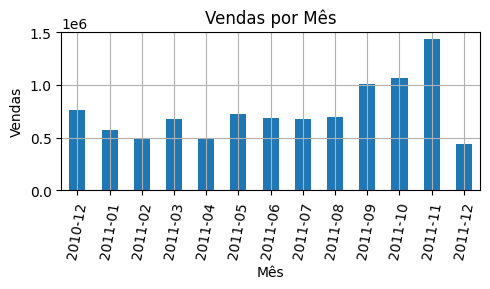

In [9]:
sales_time = df.groupby('YearMonth')['Sales'].sum()

# Plot
plt.figure(figsize=(5,3))
sales_time.plot(kind='bar')
plt.title('Vendas por Mês')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.xticks(rotation=80)
plt.grid()
plt.tight_layout()
plt.show()

### 4.2. Vendas por país

In [10]:
sales_country = (
    df.groupby('Country')['Sales']
    .sum()
    .sort_values(ascending=False) )

# Total geral
total_sales = df['Sales'].sum()
# DataFrame com valor e percentual
sales_country_df = sales_country.to_frame(name='Sales')
sales_country_df['%'] = ((sales_country_df['Sales'] / total_sales)*100).round(2)

print("\n=== Vendas por país (valor e percentual) ===")
print(sales_country_df.head(5))


=== Vendas por país (valor e percentual) ===
                     Sales      %
Country                          
United Kingdom  8236180.19  84.70
Netherlands      283373.94   2.91
EIRE             258536.33   2.66
Germany          200877.21   2.07
France           182152.90   1.87


### 4.3. Vendas por cliente


=== Gastos dos top 5 clientes ===
                Sales  % das vendas
CustomerID                         
14646.0     278672.42          2.87
18102.0     256438.49          2.64
17450.0     188505.37          1.94
14911.0     128882.13          1.33
12415.0     123638.18          1.27


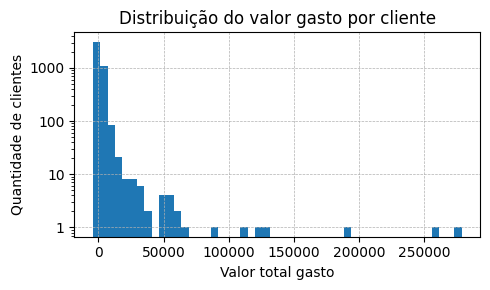

In [11]:
top_customers = ( df.groupby('CustomerID')['Sales'] .sum() .sort_values(ascending=False) .head(30)) 
top_customers_df = top_customers.to_frame(name='Sales')
top_customers_df['% das vendas'] = ((top_customers_df['Sales'] / total_sales)*100).round(2)
print("\n=== Gastos dos top 5 clientes ===") 
print(top_customers_df.head(5)) 

sales_per_customer = df.groupby('CustomerID')['Sales'].sum() 
plt.figure(figsize=(5,3)) 
plt.hist(sales_per_customer, bins=50) 
plt.yscale('log') 
plt.gca().yaxis.set_major_locator(ticker.LogLocator(base=10)) 
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter()) 
plt.title('Distribuição do valor gasto por cliente') 
plt.xlabel('Valor total gasto') 
plt.ylabel('Quantidade de clientes') 
plt.grid(True, linestyle='--', linewidth=0.5) 
plt.tight_layout() 
plt.show()

### 4.4. Top 10 produtos por vendas


In [12]:
top_products = (
    df.groupby('Description')['Sales']
    .sum()
    .sort_values(ascending=False) )

# Transformar em DataFrame
top_products_df = top_products.to_frame(name='Sales')
# Adicionar percentual
top_products_df['% das vendas'] = (top_products_df['Sales'] / total_sales * 100).round(2)

print("\n=== Top produtos por receita (valor e percentual) ===")
print(top_products_df.head(10))


=== Top produtos por receita (valor e percentual) ===
                                        Sales  % das vendas
Description                                                
REGENCY CAKESTAND 3 TIER            164762.19          1.69
WHITE HANGING HEART T-LIGHT HOLDER   99668.47          1.03
PARTY BUNTING                        98302.98          1.01
JUMBO BAG RED RETROSPOT              92356.03          0.95
RABBIT NIGHT LIGHT                   66756.59          0.69
PAPER CHAIN KIT 50'S CHRISTMAS       63791.94          0.66
ASSORTED COLOUR BIRD ORNAMENT        58959.73          0.61
CHILLI LIGHTS                        53768.06          0.55
SPOTTY BUNTING                       42065.32          0.43
JUMBO BAG PINK POLKADOT              41619.66          0.43


## 5. Análise de volume de vendas   
### 5.1. Top 10 produtos por volume

In [13]:
top_products = df.groupby('Description')['Sales'].sum().sort_values(ascending=False).head(10)
top_products_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("\n=== Top produtos por volume ===")
print(top_products_quantity.head(10))


=== Top produtos por volume ===
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64


Foi observado que os produtos mais vendidos em volume não coincidem com os que mais geram receita.

Isso indica a presença de dois perfis distintos:
- produtos de alto volume e baixo valor unitário
- produtos de menor volume, porém maior impacto financeiro

Para fins de análise de desempenho, priorizou-se a receita gerada, por refletir diretamente o impacto econômico das vendas.

## 6. Análise de clientes   
### 6.1. Comportamento de recompra dos clientes


=== Distribuição de clientes por frequência de compra ===
           Clientes  % do total
InvoiceNo                      
1              1501       34.62
2-5            1967       45.36
6-10            532       12.27
11-20           242        5.58
21-50            79        1.82
51-100           12        0.28
100+              3        0.07


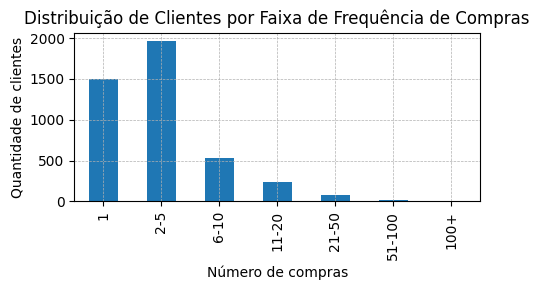

In [14]:
freq_customers = (
    df[df['Sales'] > 0]
    .groupby('CustomerID')['InvoiceNo']
    .nunique() ) # Lista de clientes, com total de compras feitas

# Faixas
bins = [0, 1, 5, 10, 20, 50, 100, float('inf')]
labels = ['1', '2-5', '6-10', '11-20', '21-50', '51-100', '100+']
freq_group = pd.cut(freq_customers, bins=bins, labels=labels, right=True, include_lowest=True)
# Contagem
distribution = freq_group.value_counts().sort_index()
# Percentual
distribution_pct = (distribution / distribution.sum() * 100).round(2)
# Juntar tudo
distribution_df = pd.DataFrame({
    'Clientes': distribution,
    '% do total': distribution_pct})

print("\n=== Distribuição de clientes por frequência de compra ===")
print(distribution_df)

plt.figure(figsize=(5,3))
distribution.plot(kind='bar')
plt.title('Distribuição de Clientes por Faixa de Frequência de Compras')
plt.xlabel('Número de compras')
plt.ylabel('Quantidade de clientes')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 6.2. Distribuição das vendas entre Clientes

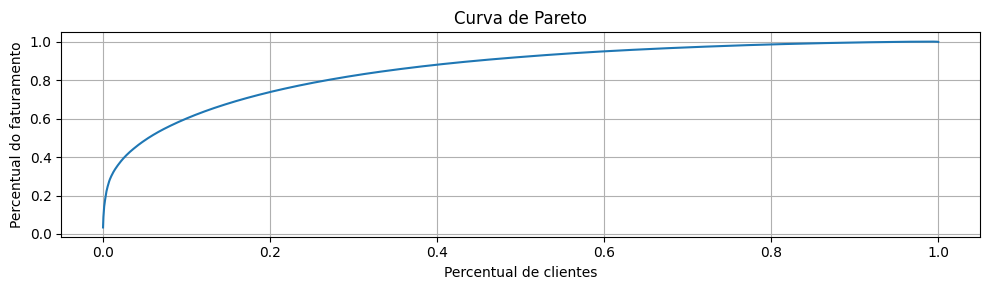

In [15]:
# Receita por cliente (ordenado)
sales_per_customer = (
    df.groupby('CustomerID')['Sales']
    .sum()
    .sort_values(ascending=False))

# Percentual acumulado
cum_revenue = sales_per_customer.cumsum() / sales_per_customer.sum()
 # Percentual de clientes
cum_clients = range(1, len(sales_per_customer) + 1)
cum_clients = [x / len(sales_per_customer) for x in cum_clients]

# Plot
plt.figure(figsize=(10,3))
plt.plot(cum_clients, cum_revenue)
plt.xlabel('Percentual de clientes')
plt.ylabel('Percentual do faturamento')
plt.title('Curva de Pareto')
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.3. Vendas por recorrência de clientes

C:\Users\littl\AppData\Local\Temp\ipykernel_33260\3252175712.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_freq = customer_df.groupby('faixa')['revenue'].sum()


  Frequência de compra  Faturamento  % do faturamento
0                    1    529232.01              6.42
1                  2-5   2064733.91             25.06
2                 6-10   1463968.32             17.77
3                11-20   1632065.53             19.81
4                21-50   1406323.36             17.07
5               51-100    944850.72             11.47
6                 100+    198371.01              2.41


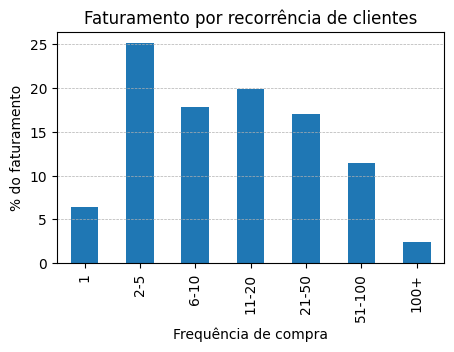

In [ ]:
# Criando tabela de frequencia de compras e vendas totais
customer_df = pd.DataFrame({
    'freq': freq_customers,
    'revenue': sales_per_customer})

# Criando faixas de recorrência
bins = [0, 1, 5, 10, 20, 50, 100, float('inf')]
labels = ['1', '2-5', '6-10', '11-20', '21-50', '51-100', '100+']
customer_df['faixa'] = pd.cut(customer_df['freq'], bins=bins, labels=labels)
# Faturamento por faixa
sales_by_freq = customer_df.groupby('faixa')['revenue'].sum()
# Percentual
sales_perc = sales_by_freq / sales_by_freq.sum() * 100

table = pd.DataFrame({
    'Frequência de compra': sales_by_freq.index,
    'Faturamento': sales_by_freq.values,
    '% do faturamento': sales_perc.values})

table['% do faturamento'] = table['% do faturamento'].round(2)
print(table)

plt.figure(figsize=(5,3))
sales_perc.plot(kind='bar')
plt.ylabel('% do faturamento')
plt.xlabel('Frequência de compra')
plt.title('Faturamento por recorrência de clientes')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.show()

### 6.4. Sinais de inatividade dos clientes
Foi explorada uma métrica baseada no intervalo entre compras, com o objetivo de identificar possíveis sinais de inatividade dos clientes. No entanto, essa análise depende de um histórico completo de transações e de contexto adicional, não sendo adequada para interpretação isolada.  

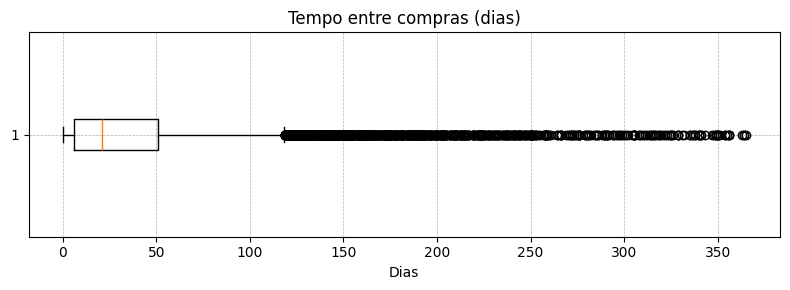

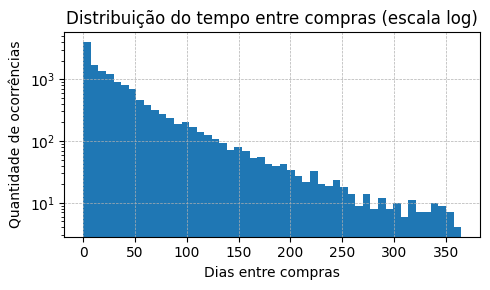

In [28]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']) # Garantir formato de data
df_valid = df[df['Sales'] > 0].copy() # Considerar apenas vendas válidas
# Manter apenas uma linha por compra
purchases = (
    df_valid[['CustomerID', 'InvoiceNo', 'InvoiceDate']]
    .dropna(subset=['CustomerID', 'InvoiceNo', 'InvoiceDate'])
    .drop_duplicates()
    .sort_values(['CustomerID', 'InvoiceDate'])
    .copy()) # Transformando numa tabela de compras sem a dependência dos produtos 

purchases['prev_date'] = purchases.groupby('CustomerID')['InvoiceDate'].shift(1) # Calcular data da compra anterior por cliente
# Calcular tempo entre compras (em dias)
purchases['days_between'] = (
    purchases['InvoiceDate'] - purchases['prev_date']).dt.days
# Remover NaN (primeira compra de cada cliente)
repurchase = purchases.dropna(subset=['days_between'])

plt.figure(figsize=(8,3))
plt.boxplot(repurchase['days_between'], vert=False)
plt.title('Tempo entre compras (dias)')
plt.xlabel('Dias')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,3))
plt.hist(repurchase['days_between'], bins=50)
plt.yscale('log')
plt.title('Distribuição do tempo entre compras (escala log)')
plt.xlabel('Dias entre compras')
plt.ylabel('Quantidade de ocorrências')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

- Observou-se que o comportamento de recompra apresenta alta variabilidade entre os clientes, o que inviabiliza o uso de um único valor médio ou mediano como referência geral.
- Há cerca de 4000 ocorrências de recompras com intervalo de 10 dias, com redução progressiva conforme o intervalo aumenta, chegando a poucas ocorrências em intervalos mais longos (por exemplo, cerca de 10 ocorrências de recompras com intervalo de 300 dias)

## 7. Exportação dos dados (LOAD)

In [17]:
df.to_csv('C:/Users/littl/OneDrive/Área de Trabalho/Dados/Portfolio/Loja/dados_tratados.csv')

## 8. Insights encontrados

**4.1 Vendas por mês**    
- A análise mensal isolada não permite identificar padrões consistentes de comportamento, sendo limitada pela ausência de dados históricos para comparação.    

**4.2 Vendas por país**   
- As vendas estão extremamente concentradas no Reino Unido, que sozinho representa cerca de 85% de todo o faturamento, enquanto os demais países têm participação muito pequena e distribuída, indicando forte dependência de um único mercado.  

**4.3 Vendas por cliente**   
- Os dados mostram que poucos clientes possuem participação representativa no faturamento, enquanto a maioria apresenta baixa participação, indicando uma distribuição desigual e concentração de receita em determinados clientes.   

**4.4 Top 10 produtos por vendas**   
- Mesmo os 10 produtos mais vendidos representam uma parcela limitada do faturamento total, reforçando a baixa concentração e a diversificação das vendas.  

**6.1 Comportamento de recompra dos clientes**  
- A maior parte dos clientes realizam poucas compras, com cerca de 35% concentrados em 1 pedido e 45% entre 2 a 5 pedidos;   
- Em contrapartida, 20% dos clientes realizam mais de 5 compras, indicando a presença de um grupo relevante com alto nível de engajamento e comportamento recorrente.   

**6.2 Distribuição das vendas entre Clientes**   
- A curva de pareto mostra que aproximadamente 30% dos clientes representam 80% do faturamento.   

**6.3 Vendas por recorrência de clientes**      
- A concentração de faturamento observada na curva de Pareto está diretamente relacionada ao comportamento de recompra, uma vez que as faixas de maior recorrência (2 a 20 compras) concentram 63% da receita; 
- Isso indica que os principais clientes da base são, predominantemente, recorrentes.   

**6.4 Sinais de inatividade dos clientes**   
- Para a alta variabilidade no comportamento de recompra recomenda-se a segmentação dos clientes com base em sua frequência típica de compra (por exemplo: semanal, mensal ou esporádica), permitindo avaliar desvios em relação ao seu próprio padrão histórico;   
- Essa abordagem possibilita a identificação mais precisa de potenciais sinais de inatividade, ao considerar as particularidades de cada cliente, em vez de aplicar critérios generalistas;   
- No entanto, essa estratégia não foi implementada neste momento, pois requer um histórico mais longo e consistente por cliente. No presente conjunto de dados, cerca de 35% dos clientes realizaram apenas uma compra, o que não caracteriza necessariamente perda, mas limita a análise de recorrência individual.   

**Observação final**
- Considerando a forte concentração das vendas no Reino Unido, análises segmentadas por país (como recorrência) tendem a apresentar baixa relevância, não sendo priorizadas nesta etapa.

## 9. Análise do negócio
- Embora cerca de 35% dos clientes realizem apenas uma compra, eles respondem por apenas 6,42% do faturamento. Por outro lado, os clientes com maior recorrência (mais de 10 compras) representam apenas 8% da base, mas concentram 51% da receita. Isso indica que o desempenho da empresa está fortemente sustentado por um grupo pequeno de clientes com alto nível de consumo.
  
- Dado que clientes recorrentes têm maior impacto financeiro, estratégias voltadas ao aumento da frequência de compra dos clientes atuais tendem a ser mais eficientes do que a aquisição de novos clientes.
- A maior parte da base realiza poucas compras e contribui pouco para o faturamento, indicando que há um potencial não explorado na conversão desses clientes em recorrentes.  
- O faturamento depende majoritariamente de clientes recorrentes, tornando a fidelização um elemento central para a sustentabilidade do desempenho.
- Clientes com frequência entre 2 e 10 compras já demonstram interesse pelos produtos da loja e representam uma oportunidade de evolução para o grupo de alta recorrência, com menor custo do que a aquisição de novos clientes.